In [71]:
import requests
from IPython.core.display import HTML
HTML(f"""
<style>
</style>
""")

# Question 10 c)
Generating models and PCA

- Generate new faces using PCA (Task 4)
- Transform vector $a$ to with basis matrix $\Phi_{k}$ new basis $\mathbf{x} = \Phi_{k} a + \mu$

- Principle Components -> A direction in the data that captures as much variation as possible.


# PCA for shape generation

**Mandatory assignment 2**
This is the second mandatory assignment, to be submitted on LearnIT as a Jupyter Notebook containing your implementation and notes by the deadline specified on [LearnIT](https://learnit.itu.dk/)
. Details on the submission process can be found [here](https://iml.itu.dk/01-about_the_course/01-AboutTheCourse.html)
.
This Assignment contains two parts. Part one is be feasible **after lecture 11**, and the second part **after lecture 12**.
The assignment applies PCA to generate face shapes. The objective is to explore the relationship between points in the latent space and their corresponding representations in the data space.


**Refresh**
The eigenvalue $\lambda_i$ is equal to the variance $\sigma_i^2$ along the direction of its eigenvector $v_i$. This equivalence allows us to use $\lambda_i$ and $\sigma_i^2$ interchangeably. Furthermore observe that the variance is given by $\sigma^2$ and hence the  standard deviation is given by $\sigma$ (standard deviation).
That is:

$$\lambda_i = \sigma_i^2$$
and therefore:

$$\sigma_i = \sqrt{\lambda_i}$$

<div style="float: none; width: 100%; justify-content: start" class="block is-clearfix">


<article class="message">
    <div class="message-body">
        <strong>Overview of mandatory tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#prep">Task 1: Data inspection</a>
            </li>
            <li>
            <a href="#get_pca">Task 2: Evaluate Principal compoenets</a>
            </li>
            <li>
            <a href="#gen">Task 3: Base face</a>
            </li>
            <li>
            <a href="#gen_reflect">Task 4: Base face reflections </a>
            </li>
            <li>
            <a href="#c">Task 5: Investigate variations in latent space</a>
            </li>
            <li>
            <a href="#interpolate">Task 6: Interpolation between two faces</a>
            </li>
            <li>
            <a href="#reflect">Task 7: Reflection</a>
            </li>
            <li>
            <a href="#correlation_eigen">Task 8: Eigenvalues and eigenvectors of correlat…</a>
            </li>
            <li>
            <a href="#Dimensionality_red">Task 9: Out of distribution generation</a>
            </li>
        </ul>
    </div>
</article>



</div>


**Important**
Solve the Introduction to PCA
 exercise part 1 **before starting on part 1 of this assignment**. 

# Part 1
## Data
The dataset used for the assigment consist of 120 landmarks (2D points) of faces (data space). A face consists of 73 (x,y)-coordinate pairs, i.e. 146 featues in total.

---
**Task 1 (easy): Data inspection👩‍💻**
1. Run the cell below to load libraries, the data and to  visualize the first 6 sample face shapes.


---

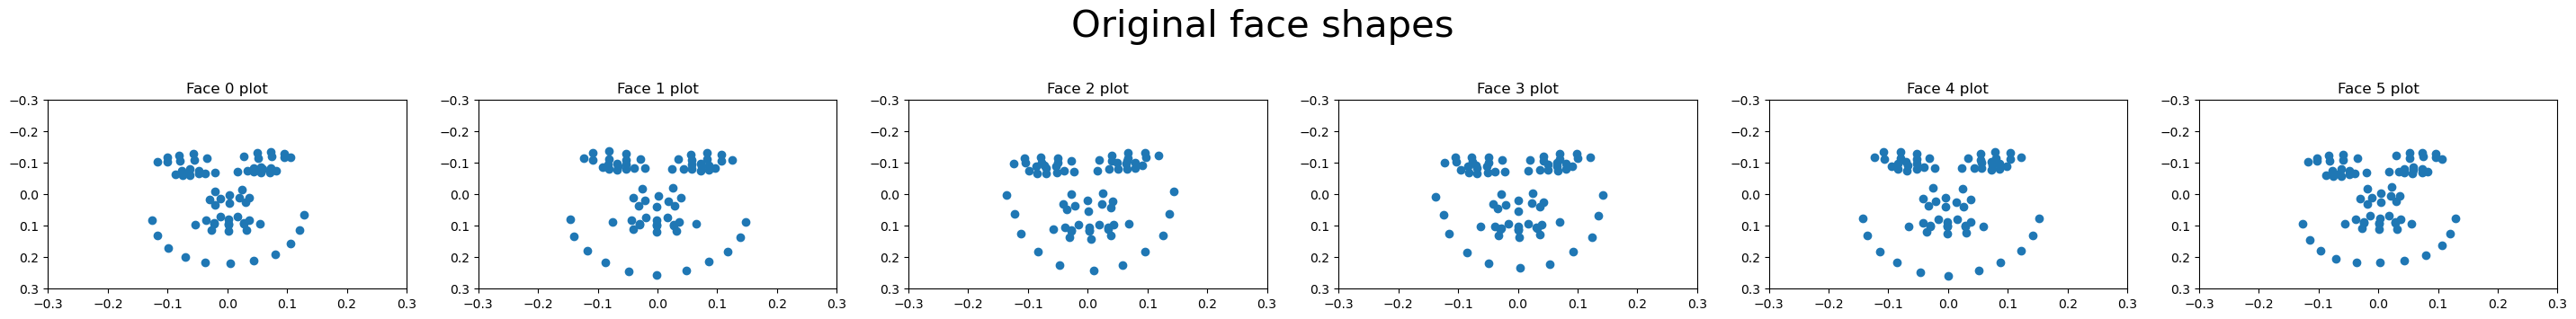

(120, 146)


In [72]:
## Importing libraries
import matplotlib.pyplot as plt
import numpy as np
import scipy
from pca_utils import *
import os
from glob import glob

path = './db/'
shapes, _ = face_shape_data(path)

plot_many_faces(shapes[:6],"Original face shapes")

print(shapes.shape)

## PCA implementation
The following tasks are about using the implementation of PCA from the in-class exercise on the face shape dataset. 

---
**Task 2 (easy): Get principal compontents👩‍💻**
1. Complete the `get_principal_components`
 function so that it returns all principal components `comp`
, eigenvalues `val`
 and mean vector `mu`
, given the dataset `shapes`
.
2. Use the `get_principal_components`
 function to calculate the principal components (`comp`
) for the face dataset.
3. Implement the function `transform_to_latent_space`
  according to the comments in the cell below using  $\mathbf{a} = \mathbf{\Phi_k}^\top(\mathbf{x}-\mathbf{\mu})$ .
4. Implement the function `transform_from_latent_space`
  according to the comments in the cell below using $x  = \mathbf{\Phi_k} \mathbf{a} + \mathbf{\mu}$ . 
5. Run the cell below to map $6$ face shapes to the latent space and back to the original data space. The `plot_many_faces`
 function is used to display both the original and the restored face shapes.
6. Visually inspect the figures and describe the reconstruction error.


---

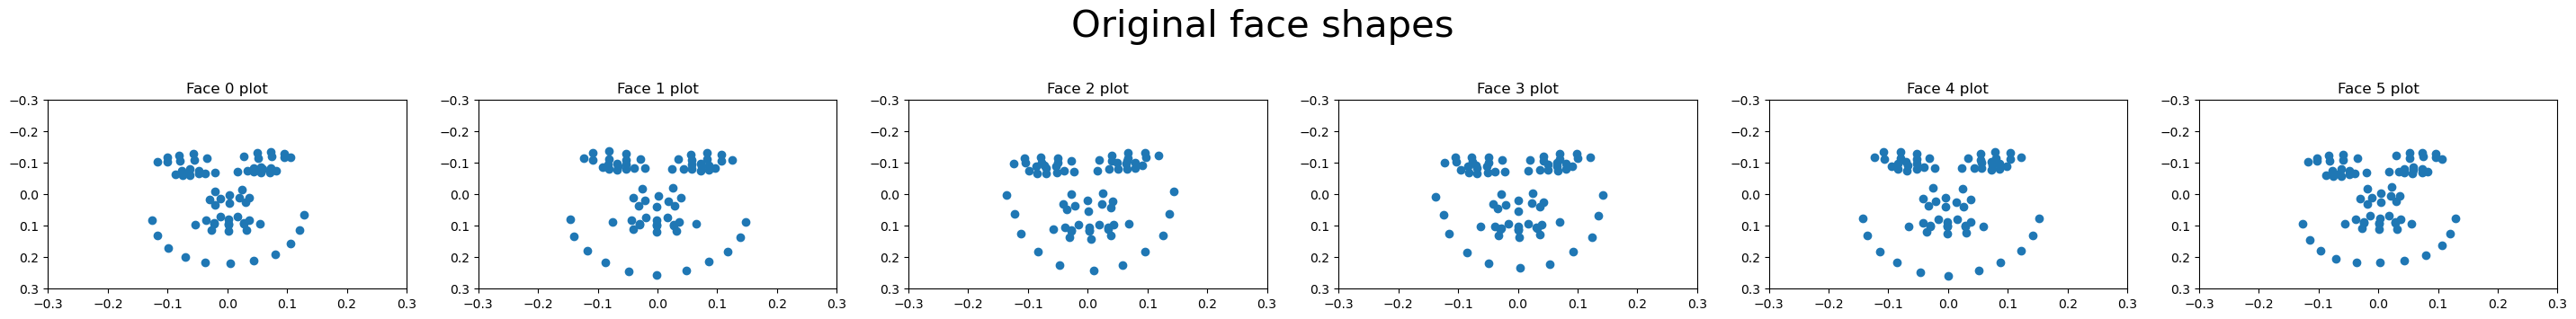

X 
 (6, 146)
principal components 
 (146, 5)


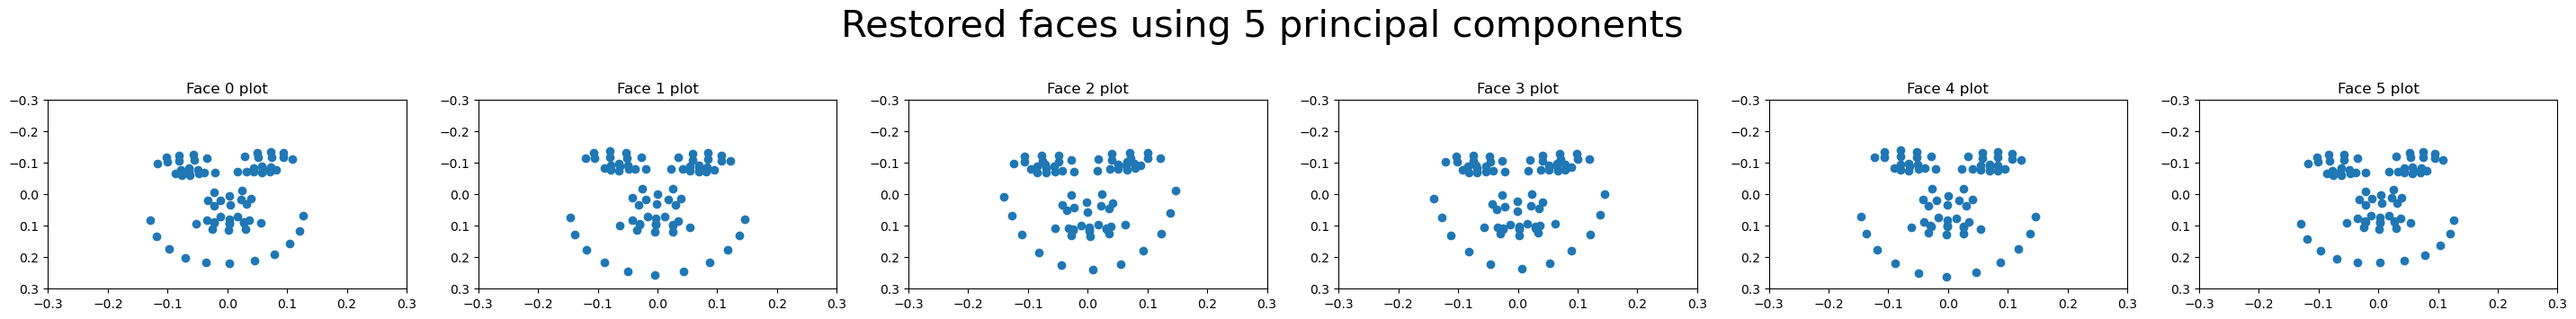

In [73]:
# 1
def get_principal_components(X):
    """Calculates principal components for X.

    Args:
        X: The dataset. An NxD array were N are the number of samples and D are
        the number of features.

    Returns:
        Tuple (components, eigenvalues, mu) where components is a DxD matrix of
        principal components, eigenvalues is a D-element vector of
        corresponding eigenvalues, and mu is a D-element array containing the mean
        vector.
    """
    #A d-dimensional mean vector, by iterating over axis 0
    mean = np.mean(X, axis=0)
    X_centered = X-mean
    covariance_matrix = np.cov(X_centered, rowvar=False)

    eigen_val, eigen_vec = np.linalg.eigh(covariance_matrix)

    # 5. Sort eigenvalues & eigenvectors in descending order
    idx = np.argsort(eigen_val)[::-1] #This is the order of the index for the sorted array
    eigen_val = eigen_val[idx]
    eigen_vec = eigen_vec[:, idx]   ## Remember to sort column wise


    #Components are eigen vector matrix
    # mean is our version of mu
    return (eigen_vec, eigen_val, mean)


# 2, 3 and 4
# Get the principal components for the dataset and transform the faces to feature space.
comp, val, mu = get_principal_components(shapes)

# write code for finding the cumulative proportional variance here

# selecting 5 components 
n_components = 5


# 5
def transform_to_latent_space(X, principal_components, mu):
    """Transforms X to an k-dimensional space where k is the number of
    principal_components.

    Args:
        X: The dataset. An NxD array were N are the number of samples and M are
        the number of features.
        principal_components: An Dxk matrix containing the principal
        components. (aka. phi_k)
        mu: A D-element array containing the mean vector.

    Returns:
        A Nxk array describing the transformed data.
    """
    print("X \n", (X-mu).shape)
    print("principal components \n", principal_components.shape)
    return np.dot((X-mu), principal_components) # Transformation

    
# 6  
def transform_from_latent_space(v, principal_components, mu):
    """Reverses the dimensionality reduction of v, a Nxk matrix where
    k is the number of principal components. The result is a NxD matrix.

    Args:
        v: The transformed (latent space) dataset with size Nxk.
        principal_components: An Dxk matrix containing the principal
        components.
        mu: A D-element array containing the mean vector.

    Returns:
        An NxD array reconstruction of the original feature vectors X.
    """
    return np.dot(v,principal_components.T)+mu

    
# 7     
used = comp[:, :n_components]

# transforming and reconstructing the 6 first faces in the dataset
plot_many_faces(shapes[:6],"Original face shapes")
transformed = transform_to_latent_space(shapes[:6], used, mu)
restored = transform_from_latent_space(transformed, used, mu)
plot_many_faces(restored,"Restored faces using 5 principal components")



---
**Task 3 (easy): Evaluate Principal compoenets💡**
1. How many components are needed to retain $50\%$, $60\%$, $80\%$, $95\%$ of the total variation?
2. Seting $k=5$ components. How much of the total variance is retained?
3. Visually inspect the figures and describe the reconstruction error.


---

In [74]:
#Write your reflections here...

# -------- 1 ---------
total_variance = np.sum(val)


def get_component_amount (percantage, var):
    total_variance = np.sum(var)
    acc = 0
    for idx,lamda in enumerate(var):
        acc += lamda
        if acc >= (percantage*total_variance):
            return (idx+1, acc)

print(get_component_amount(0.5, val))
print(get_component_amount(0.6, val))
print(get_component_amount(0.8, val))
print(get_component_amount(0.95, val))

# So to get 50% of total variation we need 2 components
# To get 60% of total variation we also need 2 components
# To get 80% of total variation we need 4 components
# To get 95% of total variation we need 8 components

# --------- 2 -----------
k_components = val[:5]
k_components_sum = np.sum(k_components)

print(k_components_sum/total_variance)

# This means that with 5 components we get 87% of the total variance.

# --------3-------

# In general the original face shape and the reconstructed face shape look very similar. We see some differences 
# with some of the faces being flattened out a little bit. But we would say that there seem to be a small 
# reconstruction error.      


(2, np.float64(0.005577573985736939))
(2, np.float64(0.005577573985736939))
(4, np.float64(0.007117881176785287))
(8, np.float64(0.008185256184105977))
0.8742165232463095



**Important**
Solve the Introduction to PCA
 exercise part 2 **before starting on part 2 of this assignment**. 

# Part 2
## Using PCA for shape generation
The principal components can be used to generate new samples $\mathbf{x}$ in data space by transforming a point in latent space according to 
$$\mathbf{x} = \Phi_{k} a + \mu$$
 where $\Phi_{k}$ is the matrix of k eigenvectors, $\mathbf{a}\in\mathbb{R}^{k}$ is a vector in latent space, and $\mu\in\mathbb{R}^{D}$ is the mean vector of the original data features in  the data space.

$$

{\Phi_k} = \begin{bmatrix} | & | & & | \\ {v}_1 & {v}_2 & \cdots & {v}_k \\ | & | & & | \end{bmatrix}

$$
The variance of the data in a given direction can be used to constrain the values of the elements of the vector $\mathbf{a}$ in latent space, assuming that the data follows a (multivariate) normal distribution. In a multivariate normal distribution each direction $v_i$ is also normally distributed. Each element $a_i$ can be constrained to be within the observed variance in direction $v_i$. The variance $\sigma_i^2$ in the direction of $v_i$ is given by the eigenvalue $\lambda_i$, so the standard deviation is  $\sigma_i = \sqrt{\lambda_i}$.
In a 1D normal distribution (with mean $\mu$ and standard deviation $\sigma$), the area under the Gaussian curve between $\pm 3\sigma$ contains $99.7\%$ of the data (see [Figure 1](#normal) ). Thus, constraining each element $a_i$ to the interval $[-3\sigma_i, 3\sigma_i]$ will cover $99.7\%$ of the variance in the direction of $v_i$. 
<div class="has-text-centered">
<figure class="image is-inline-block" id="normal">

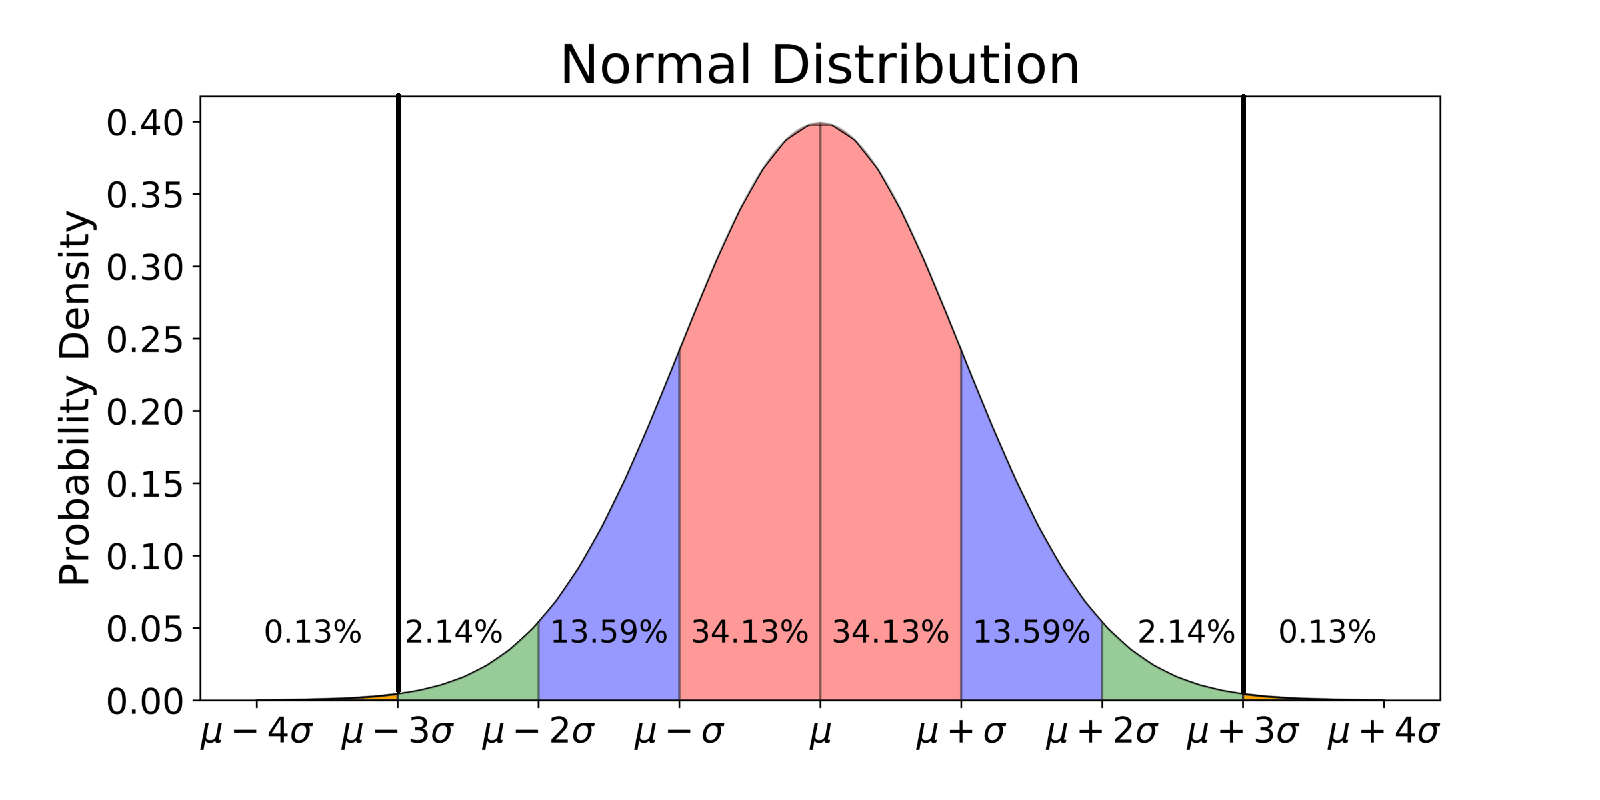

<figcaption class="figure-caption has-text-centered">Figure 1: Illustration of a normal distribution. The vertical lines mark the region covering $99.7\%$ of the variance. The shaded regions indicate the
area of the distribution covered by 1, 2, 3, and 4, standard deviations
($\sigma$) respectively.
</figcaption>
</figure>
</div>

---
**Task 4 (medium): Base face👩‍💻**
1. **Generate vectors:** run the cell below to create the zero vector in latent space, i.e. $\mathbf{a} = [0, 0, \dots, 0]\in\mathbb{R}^5$.
2. **Shape generation:** use $\mathbf{x} = \mathbf{\Phi} \mathbf{a} + \mathbf{\mu}$ to generate a face (vector in real space) from the vector $\mathbf{a}$. Use the `plot_face`
 function to visualise the generated face.
3. Change the elements of $\mathbf{a}$ to the values below, where $\lambda_i$ is the i-th eigenvalue and plot the resulting shapes for each modification:    - $\mathbf{a} = [\sqrt{\lambda_1},0, 0, 0, 0]$ $\in\mathbb{R}^5$? 
    - $\mathbf{a} = [0,-3\sqrt{\lambda_2}, 0, 0, 0]$ $\in\mathbb{R}^5$?




---

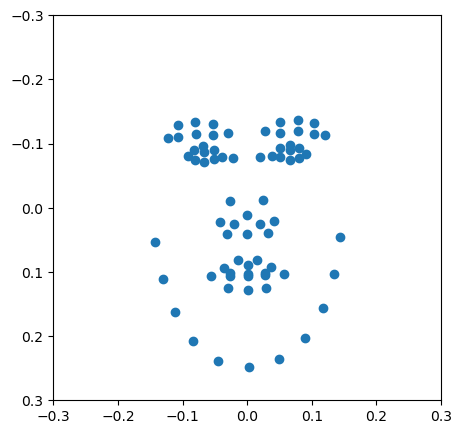

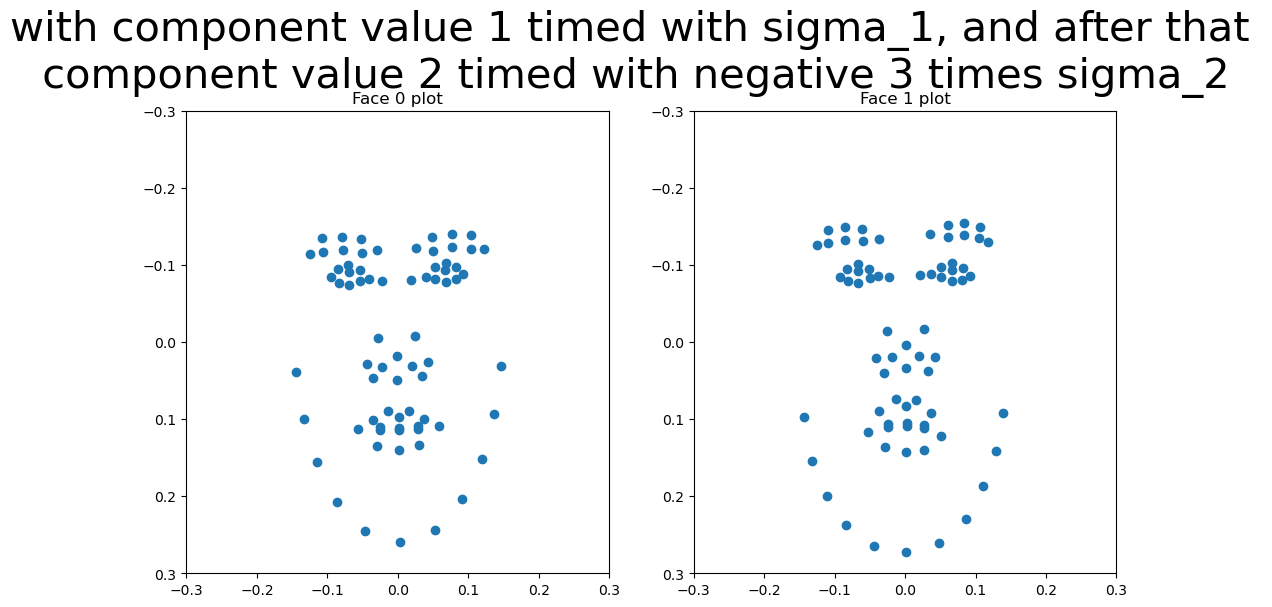

In [ ]:
# ----------- 1 ------------
a = np.array([0,0,0,0,0])

# Write your implementation here.

# -------- 2 --------
x_1 = (np.dot(used, a)) + mu  # Generate average face
plot_face(x_1)

# ------- 3 --------
a_1 = np.array([(np.sqrt(val[0])),0,0,0,0]) #Val has been 0 indexed, instead
x_2 = (np.dot(used, a_1)) + mu


a_2 = np.array([0,(-3*np.sqrt(val[1])),0,0,0]) #Val has been 0 indexed, instead # Mouth changed
x_3 = (np.dot(used, a_2)) + mu

plot_many_faces([x_2, x_3], "with component value 1 timed with sigma_1, and after that \n component value 2 timed with negative 3 times sigma_2 \n")



---
**Task 5 (medium): Base face reflections 💡**
1. Use $\mathbf{x} = \Phi_{k} a + \mu$ to explain what the vector $a \in R^5$ represents if     
    - $\mathbf{a}= [0,0,0,0,0]$?
    - $\mathbf{a} = [\sqrt{\lambda_1},0, 0, 0, 0]$? 
    - $\mathbf{a} = [0,-3\sqrt{\lambda_2}, 0, 0, 0]$?


2. Describe what face is generated and why.


---

In [76]:
# Write your reflections here

# -------- 1 ---------
# In x_1 we dot phi with a zero vector, meaning that the face is created from the mean.
# in x_2 we get the eigen vector with the most variance. We weight the first eigen vector with the first pricipal component, 
# i.e. the first eigen vector is scaled.
# In x_3 the second eigenvector is scaled with -3 times its priciple component, i.e. we decrase the value of the second eigen vector.

# --------- 2 ---------
# x_1 is the average face, since it is generated from the mean.
# x_2 is one standard deviation away from the average face, so the faces look very similar, and it is hard to see the difference.
# x_3 is three standard deviations away from the average face, and we also see a big difference in face shape, 
# and the size of the mouth and nose.


## Investigating principal components
The following tasks are about investigating properties of principal components.

---
**Task 6 (medium): Investigate variations in latent space👩‍💻**
1. **Varying the 1st component:** Let $\mathbf{a} \in \mathbb{R^5}$ be a vector in the latent space. Generate 5 different vectors where only the first element, $a_1$, varies, while the remaining elements, $a_2, a_3, a_4, a_5$, are set to 0. Use `np.linspace`
 to generate 5 evenly spaced values for $a_1$ in the interval $[-3\sigma_1, 3\sigma_1]$. For each value of $a_1$, generate a corresponding face and display all 5 faces in a plot. 

2. **More components:** Do the same for each of the remaining four components, i.e. $a_2$-$a_5$ leaving the others as 0. 

3. **Component analysis:** Describe how each principal component changes the face shape (for example, the first component may change the length of the face). 



---

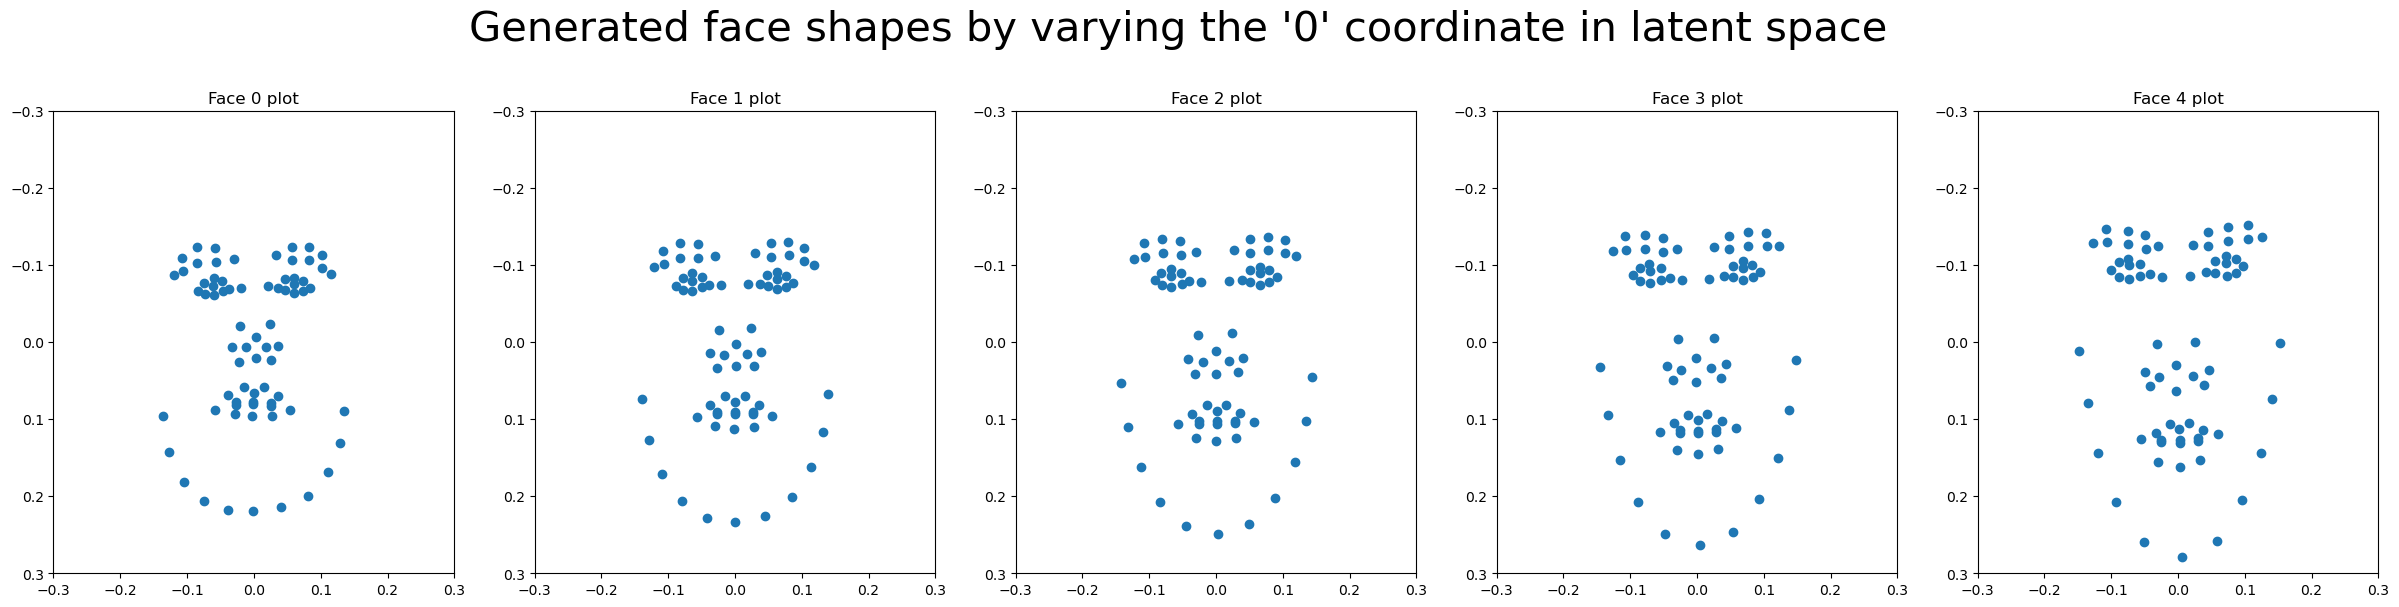

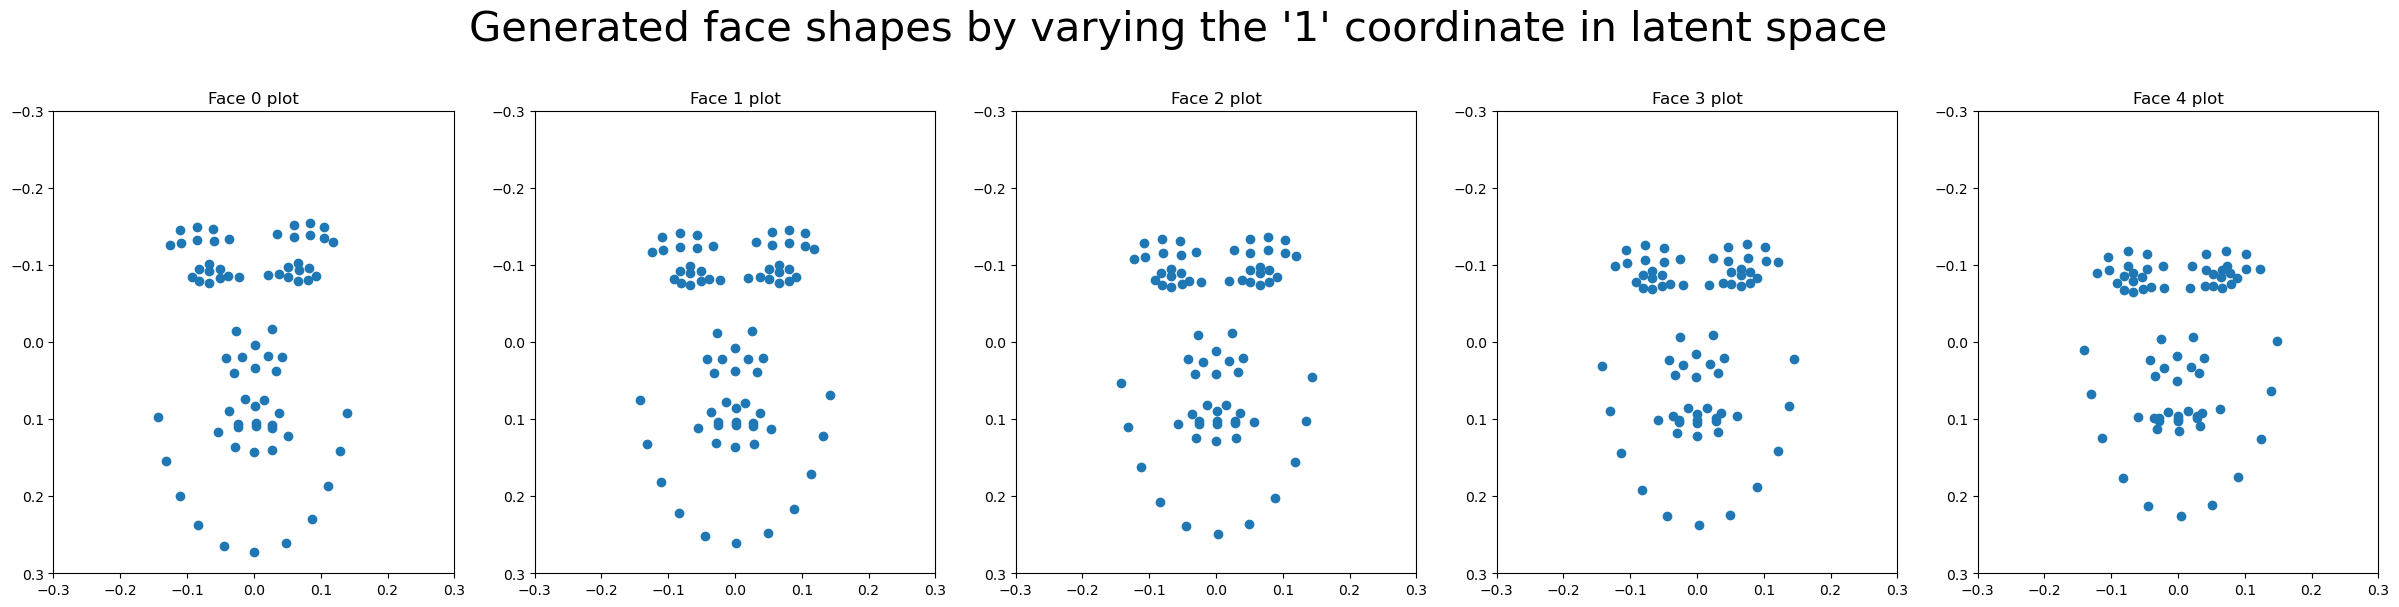

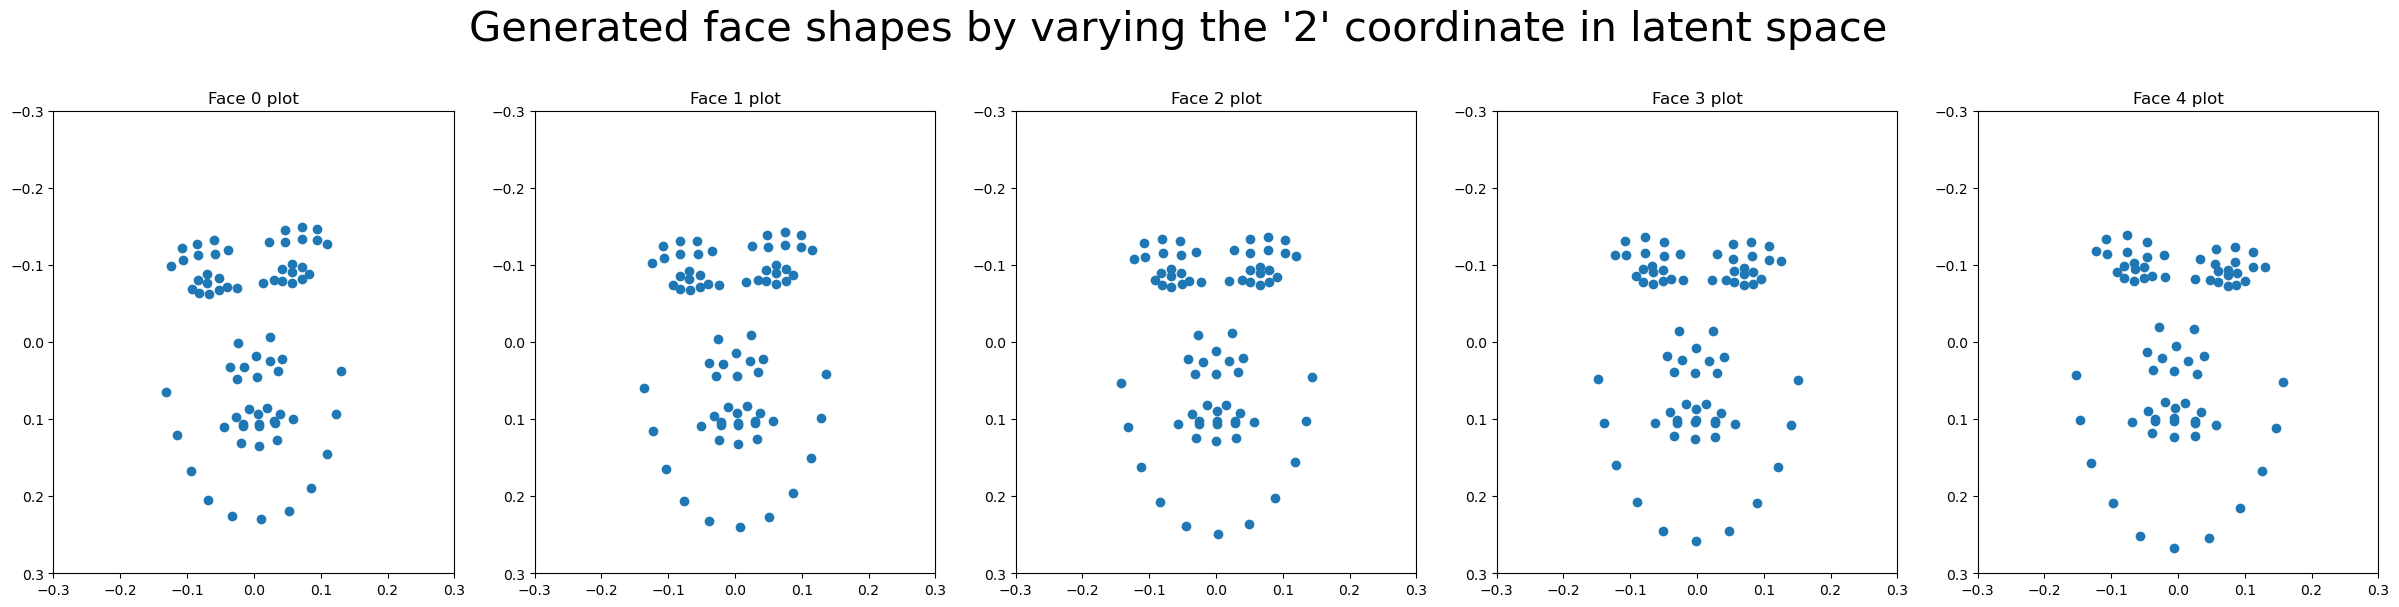

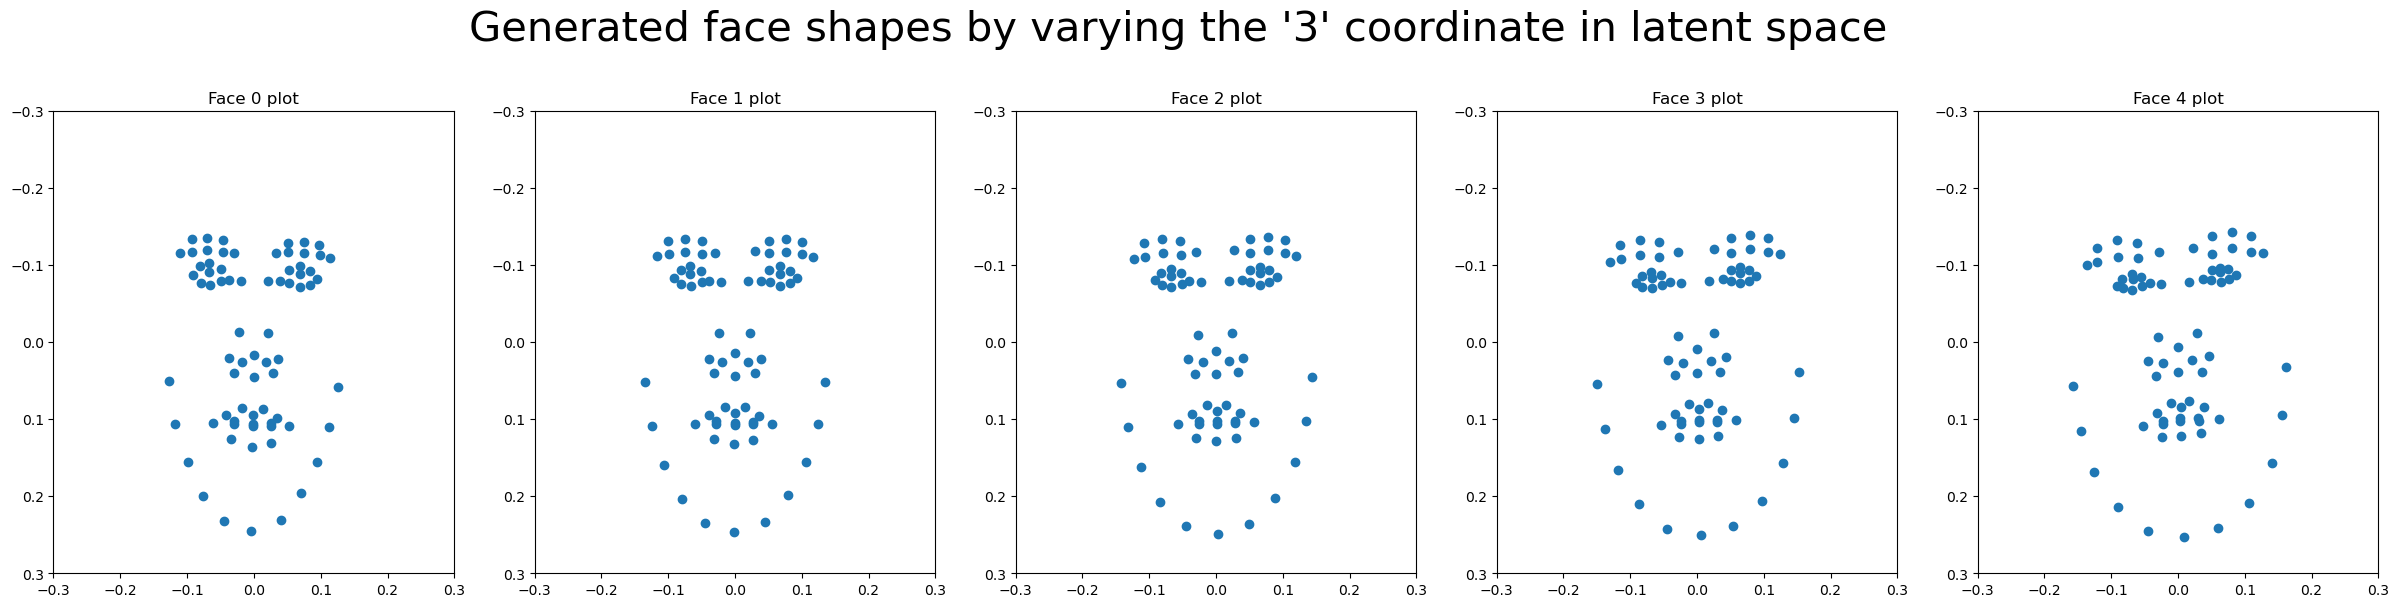

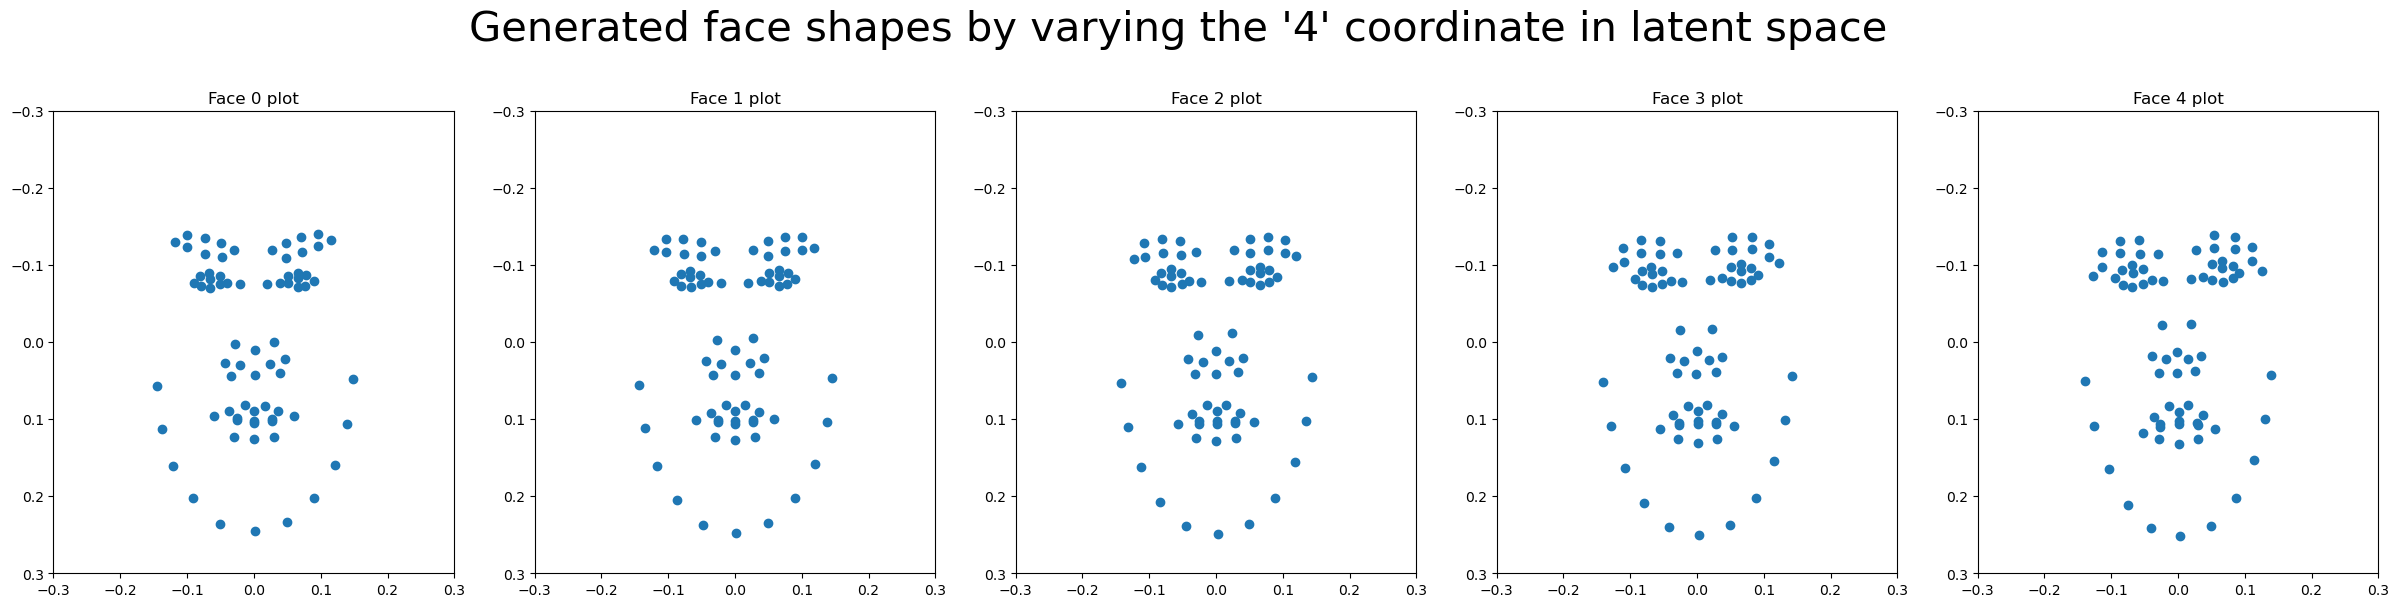

In [77]:
# --------- 1 ----------
# --------- 2 ----------

def generate_faces_from_components(eigen_value_idx, val):
    std_1 = np.sqrt(val[eigen_value_idx]) # std/eigvalue for the first PC
    values_1 = np.linspace(-3*std_1, 3*std_1, num=5)
    base_weight_idx = np.zeros(5)

    # Write your solution here
    gen_shapes = []
    for val in values_1:
        weight_vector = np.copy(base_weight_idx)
        weight_vector[eigen_value_idx] = val
        # print(weight_vector)
        x = (np.dot(used, weight_vector)) + mu
        gen_shapes.append(x)

    plot_many_faces(gen_shapes,f"Generated face shapes by varying the '{eigen_value_idx}' coordinate in latent space")

generate_faces_from_components(0, val)
generate_faces_from_components(1, val)
generate_faces_from_components(2, val)
generate_faces_from_components(3, val)
generate_faces_from_components(4, val)



In [78]:
# -------- 3 -----------

# The first principle component influences the face shape. Mostly the hight of the whole face, 
# meaning both how for the chin goes as well as the distance between eye-brows and mouth.
# If we speculate, it could look a little like the angle of the face, where negative 3 standard deviations looks 
# like we are looking at the person from below, while 3 standard deviations looks like we are looking from above

# The second principle component changes the distance between points/the spacing in these,
# changing both the width and lengths of the faces and their facial features

# The third changes the angle of the face, meaning whether the face is tilted to the left or right

# the fourth changes the pointy-ness of the chin

# and the fith changes the facial feature, including eyebrow shapes, eye size, nose width and mouth tilt. 
# But in these, most notably the angle of the eyebrow shapes.


## Interpolating between shapes
The following example shows how to interpolate two vectors.


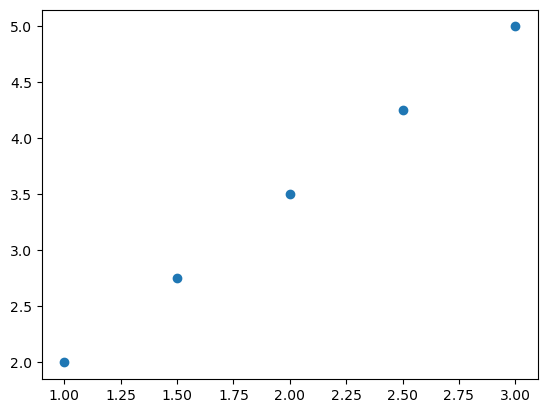

In [79]:
# #Template for doing interpolation between two (2D)- points 
d = np.linspace(np.array([1, 2]), np.array([3, 5]), num=5)
plt.scatter(d[:, 0], d[:, 1])


---
**Task 7 (medium): Interpolation between two faces👩‍💻**
**Shape Interpolation:**
1. Select points $\mathbf{a}$ and $\mathbf{b}$ in latent space (paying attention to the Gaussian constraints) and generate the faces.
2. Use `np.linspace`
 to generate 6 evenly spaced points that interpolate between two vectors, $\mathbf{a}$ and $\mathbf{b}$, in the latent space. Plot the resulting faces. 
3. Select $\mathbf{a}$ and $\mathbf{b}$ such that:    
    - $\mathbf{a}$ = $[-3\lambda_1,0,-3\lambda_3,0,0]$ and $\mathbf{b}$ = $[3\lambda_1,0,3\lambda_3,0,0]$.
    - $\mathbf{a}$ = $[0,5\lambda_2,0,0,0]$ and $\mathbf{b}$ = $[0,-5\lambda_2,0,0,0]$.
    - the generated shapes represent a smile.

# Extra notes for our implementation!
We have chosen to take the standard deviation, (i.e. $\sqrt{\lambda}$) instead of lambda for task 3, due to this being more visible. If we chose to use lampda, it would probably still be visible, but not as visible as using the standard deviation.
This is also confirmed to be correct by a TA, see post under here:
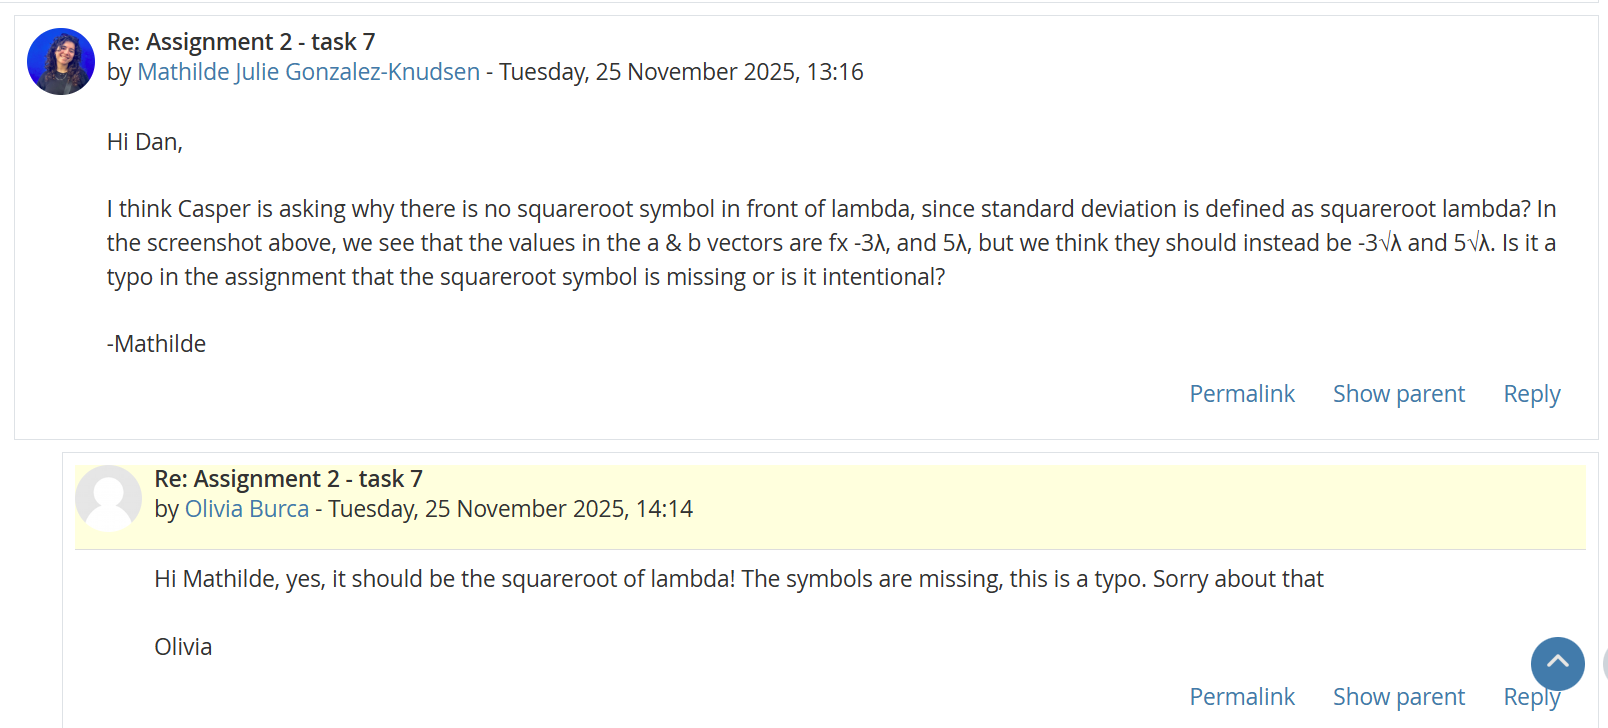


---

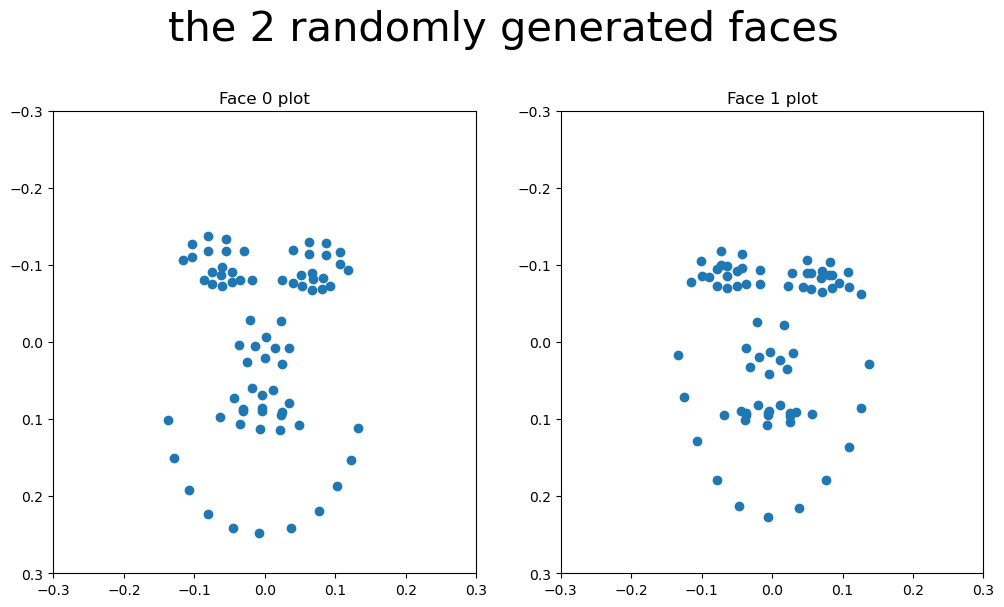

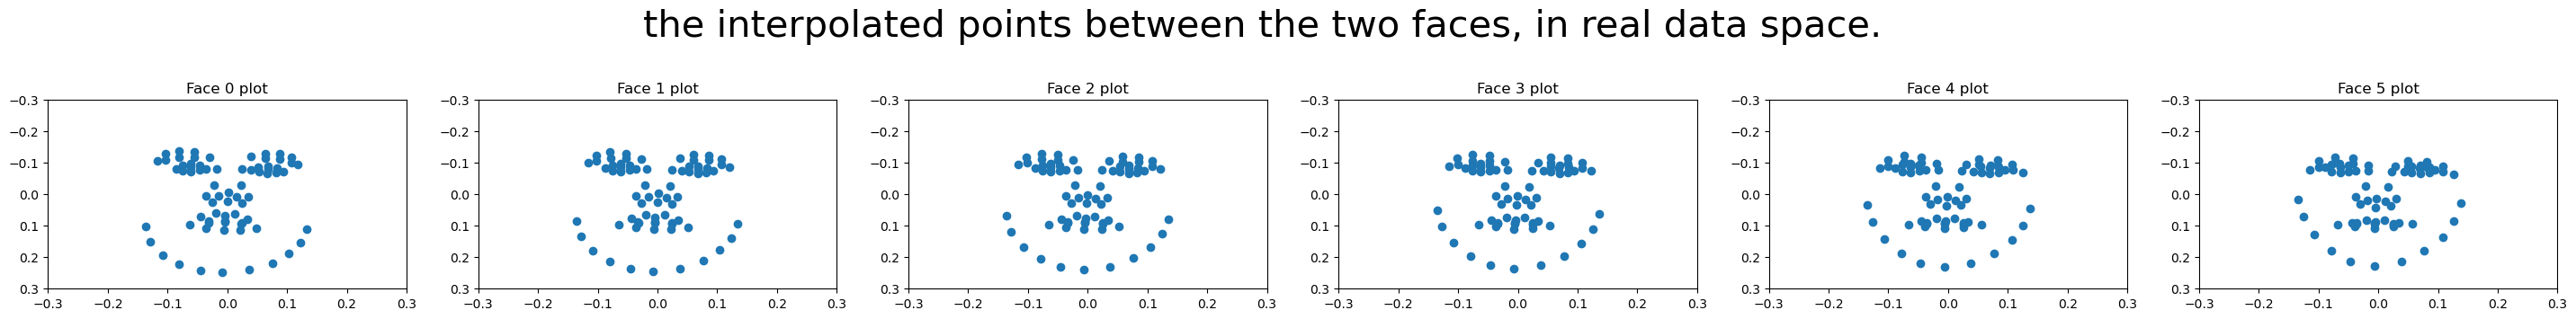

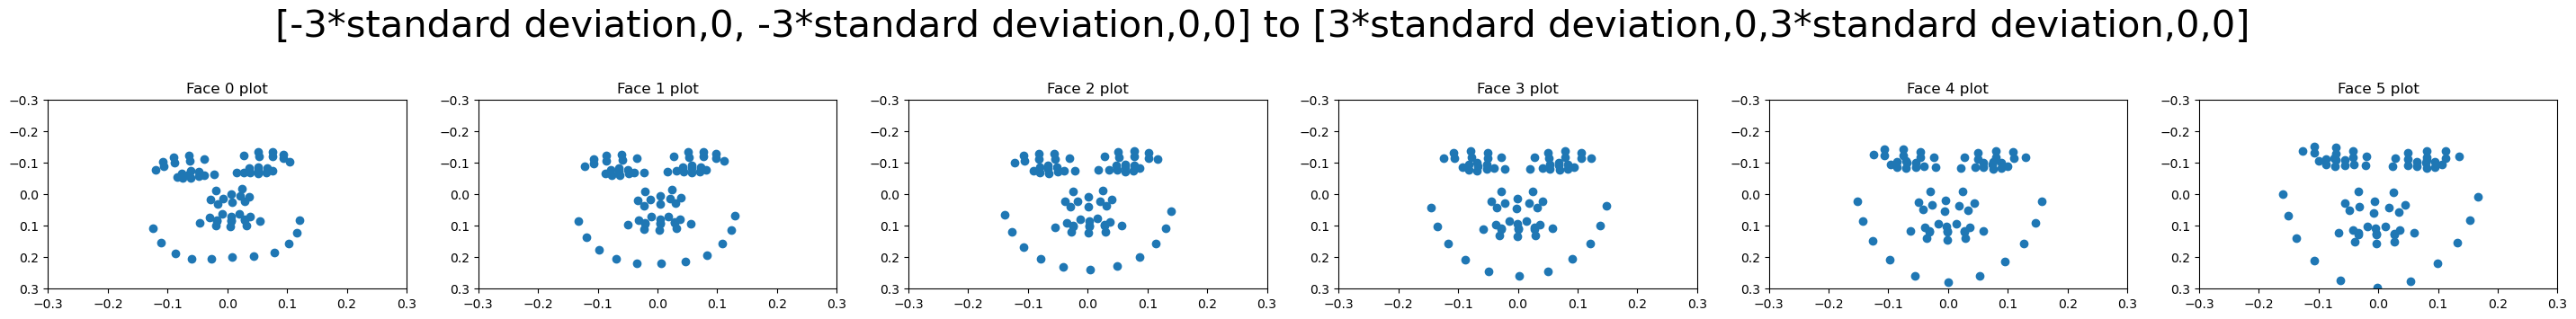

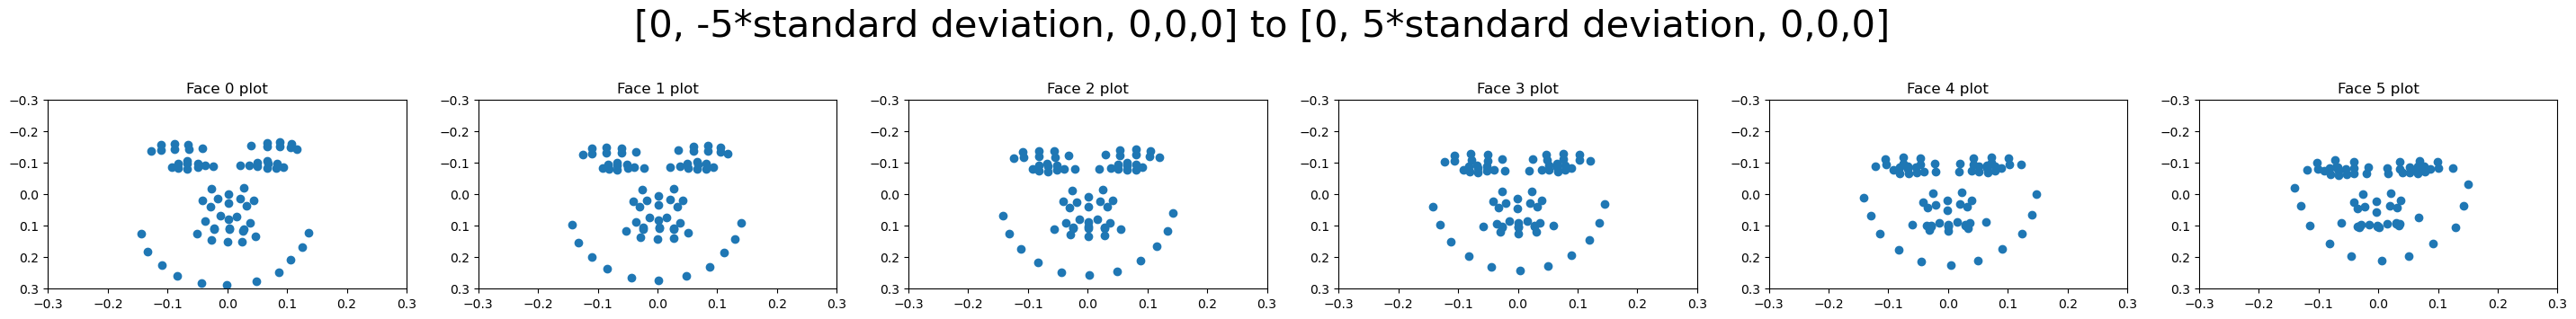

In [80]:
# write the implementation for "Interpolation between two faces" here

#  ------------------- NOTICE ----------------
# We have chosen to assume when the assignment writes eigen values, that they actually mean
# standard deviation, due to else this is not possible to see any difference, due to
# the low amount of numbers then.


face_list_ran = []
face_list_x = []
face_list_y = []

# Helper function for generating a random point between -3 standard deviation and +3 standard deviation.
def pick_with_gaussian_constraint(idx):
    return np.random.uniform(-3*np.sqrt(val[idx]), 3*np.sqrt(val[idx]))



# Create the vector 'a' by just choosing 5 random values that adhere to the Gaussian distribution
temp = np.zeros(5)
for i in range(5):
    temp[i] = pick_with_gaussian_constraint(i)
a_ran = np.copy(temp)

# Create the vector 'b' by just choosing 5 random values that adhere to the Gaussian distribution
temp = np.zeros(5)
for i in range(5):
    temp[i] = pick_with_gaussian_constraint(i)
b_ran = np.copy(temp)

plot_many_faces([(np.dot(used, a_ran)) + mu, (np.dot(used, b_ran)) + mu], "the 2 randomly generated faces")

#Create the linear space
lin_ran = np.linspace(a_ran, b_ran, num=6)


# Here we then show the interpolated points between the two faces, in real data space
for i in range(6):
    lin_ran_plot = (np.dot(used, lin_ran[i])) + mu
    face_list_ran.append(lin_ran_plot)
plot_many_faces(face_list_ran, "the interpolated points between the two faces, in real data space.")


# ----------- 3 --------------

a_x = np.array([-3*np.sqrt(val[0]),0, -3*np.sqrt(val[2]),0,0])

b_x = np.array([3*np.sqrt(val[0]),0,3*np.sqrt(val[2]),0,0])

lin = np.linspace(a_x, b_x, num=6)


for i in range(6):
    lin_x = (np.dot(used, lin[i])) + mu
    face_list_x.append(lin_x)

plot_many_faces(face_list_x, "[-3*standard deviation,0, -3*standard deviation,0,0] to [3*standard deviation,0,3*standard deviation,0,0]")



a_y = np.array([0,-5*np.sqrt(val[1]),0,0,0])

b_y = np.array([0,5*np.sqrt(val[1]),0,0,0])

lin_2 = np.linspace(a_y, b_y, num=6)

for i in range(6):
    lin_y = (np.dot(used, lin_2[i])) + mu
    face_list_y.append(lin_y)

plot_many_faces(face_list_y, "[0, -5*standard deviation, 0,0,0] to [0, 5*standard deviation, 0,0,0]")




---
**Task 8 (medium): Reflection💡**
Describe and reflect on the results obtained from this assignment, the exercises and the in-class exercises. Answer the following questions:
1. **Behaviour:** Explain why, a set of points interpolated on a line in latent space corresponds to a sample on a line in data space using $x = \Phi\mathbf{a} + \mu$. 
2. How well can a few principal components reproduce the samples? What happens with the generated data when the number of components $k$ is changed to 1,3,9, or 15?


---

In [81]:
# -------------- 1 ----------------

# Because this mapping from latent space to data space is affine, by linearly
# calculating the points positions (by 'phi' and 'a'), and then translating it to be at
# the correct position by 'my'. 

# Affine transformations do not bend, warp, or curve space — 
# they only scale, stretch, rotate, shear, and shift it.

# Therefore a interpolated line in the latent space, is also an interpolated line in 
# data space.

# So in addition, despite changes in dimentions, the PCA allows us to keep the relative relations between the data points using eigen-vetors 
# in the principle component matrix to interpolate in a 2D space to then convert back into the original data space.

# ---------- 2 -----------

# The principle components are sorted after the amount of variance they explain in 
# the data - so when k is set to 1 the eigenvector of most variance is kept but 
# this is then the only thing that is kept.
# As k is set to larger numbers more 
# variance is included given a more nuanced picture, highligting more variance,
# but as explained earlier, the more k chosen, the less variance these k values explain.

# For 3, it would then the be the 3 eigen vectors with the most variance that 
# are kept. This is the same for then 9 and 15.

# From our in-class exercises and other exercises, we have experienced that it can
# differentiate some of the data, but the lower k value, the more variance is lost 
# during the transformation.


## Last section - optional
This final section includes three tasks that offer valuable insights into the application of PCA, however completing this section is optional.

---
**Task 9 (medium): Eigenvalues and eigenvectors of correlation matrix _(optional)_👩‍💻💡**
1. Implement the function `get_principal_components_correlation`
 according to the comments in the cell below.
2. Use the provided code to display the eigenvalues of the correlation matrix.
3. How do the eigenvalues obtained from the covariance matrix compare to those from the correlation matrix in terms of magnitude and the variance each principal component explains? What does this reveal about the effect of feature scaling on PCA results?


---

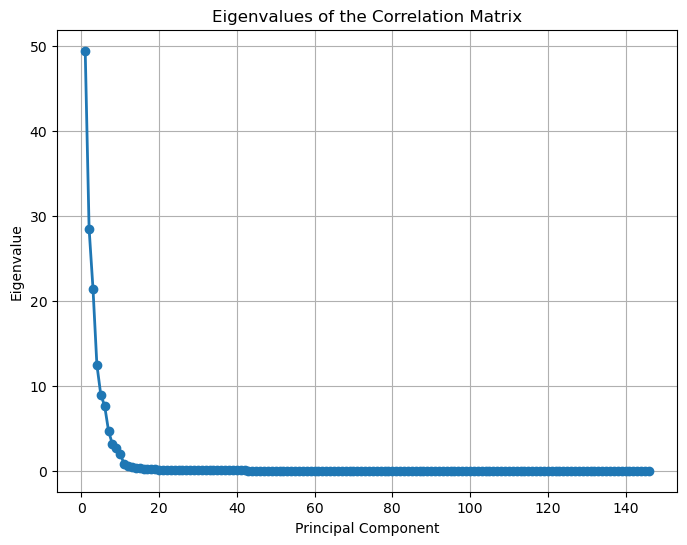

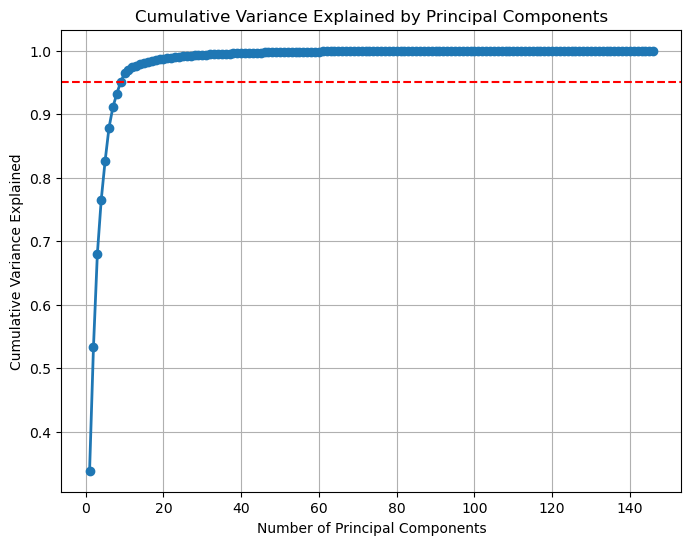

In [82]:
# ----- OUR NOTES!!!!! ---------
# The reason that we need to standardise it, is for creating the Correlation matrix. Else 
# this is not possible to create this!
# When standardized we are not looking at distance (all is scaled to max 1), 
# but more movement for example.

# What they probably want us to know is that:
# PCA on covariance -> finds main shape deformations.
# PCA on correlation -> finds correlated movement patterns, not scale-driven variance.

def get_principal_components_correlation(X):
    """Calculates principal components using the correlation matrix for X.

    Args:
        X: The dataset. An NxD array where N are the number of samples and D are
        the number of features.

    Returns:
        Tuple (components, eigenvalues, mu) where components is a DxD matrix of
        principal components, eigenvalues is a D-element vector of
        corresponding eigenvalues, and mu is a D-element array containing the mean
        vector.
    """
    # Standardize the data
    mu = np.mean(X, axis=0)
    standard_deviation = np.std(X, axis=0, ddof=1) # ddof is for saying n-1(in the denominator) when calculating this standard deviation.
    X_standardized = (X - mu) / standard_deviation

    # Compute the correlation matrix
    Correlation_matrix = np.corrcoef(X_standardized, rowvar=False)

    # Eigen-decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(Correlation_matrix)

    # Sort eigenvalues/eigenvectors (descending order)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    return (eigenvectors, eigenvalues, mu)

# Use the function on the shapes data
eigenvectors_corr, eigenvalues_corr, mu_corr = get_principal_components_correlation(shapes)

# Optionally, plot the eigenvalues to see their distribution
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(eigenvalues_corr) + 1), eigenvalues_corr, 'o-', linewidth=2)
plt.title('Eigenvalues of the Correlation Matrix')
plt.xlabel('Principal Component')
plt.ylabel('Eigenvalue')
plt.grid(True)
plt.show()

variance_explained = eigenvalues_corr / np.sum(eigenvalues_corr)
cumulative_variance_explained = np.cumsum(variance_explained)

# Plot cumulative variance explained
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance_explained) + 1),
         cumulative_variance_explained, 'o-', linewidth=2)
plt.title('Cumulative Variance Explained by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.axhline(y=0.95, color='r', linestyle='--')  # Line to indicate 95% variance
plt.grid(True)
plt.show()

In [83]:
# ----------- 3 --------------
# If we compare the eigenvalues from the covariance matrix to the eigenvalues 
# of the correlation matrix, it looks like it is about the same variance each has, and for 
# describing 95% of the variance it is about 9 for the correlation matrix, which is also 
# very close to the 8 components needed for the covariance matrix.

# The direct difference is that Eigenvalues from the covariance matrix show the 
# direct variances of the original features, so a component that desribes a feature with large
# scaling dominates the variance alot, while eigenvalues from the correlation matrix are more 
# balanced because all features are standardized to variance 1. 
# Feature scaling changes what PCA finds by making all features contribute equally, 
# so PCA focuses on their relationships instead of being dominated by large-scale features.


---
**Task 10 (medium): Dimensionality reduction of features _(optional)_👩‍💻💡**
1. **Transform data:** Use $\mathbf{\Phi^{\top}}$​ to transform the data $\mathbf{x}$ into its latent-space representation $\mathbf{x'}$ (using $\mathbf{x'}= \mathbf{\Phi^{\top}}(\mathbf{x}-\mathbf{\mu})$).
2. Plot the first two  components in latent space using a scatterplot.    - What does this plot tell you about the distribution of faces?
    - Try plotting different pairs of components. Describe how each combination separates (clusters) the dataset differently.


3. **Interpolate between real faces:** Re-implement [Task 6](#interpolate) but instead of selecting 2 points in latent space, transform two real faces to latent space and interpolate between them.     - Plot the faces of the interpolated points.




---

In [84]:
# Write implementation here

Describe the different scatter plots of component combinations

---
**Task 11 (medium): Out of distribution generation _(optional)_👩‍💻💡**
1. **Extreme values:** What happens if you select values outside the suggested range. Explain why this happens.


---

In [85]:
# Write implementation and reflections here